#### Importing required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Data Loading

In this section, we load the required datasets for the analysis.

For the initial investigation, we start with the Orders dataset because it contains the delivery-related timestamps required to identify delayed orders.

In [2]:
orders_original=pd.read_csv("data/olist_orders_dataset.csv")
orders_original.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


#### Initial Dataset Inspection
The goal of this step is to understand structure of the data,identifying important columns,inspect data types on the high level and to identify missing values if any.

In [3]:
orders_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


#### Observations
- The dataset contains 99441 entries

#### Data cleaning

In [4]:
date_columns=["order_purchase_timestamp",\
              "order_approved_at",\
              "order_delivered_carrier_date",\
              "order_delivered_customer_date",\
              "order_estimated_delivery_date"]

for col in date_columns:
    orders_original[col]=pd.to_datetime(orders_original[col])

In [5]:
orders_original[date_columns].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

#### Handling missing values

In [6]:
orders_original["order_delivered_customer_date"].isnull().sum()

np.int64(2965)

#### observation
- There are 2000 missing entries in the order_delivered_customer_date field.These likely represent specific order statuses, such as processed, shipped, cancelled, invoiced, or unrecorded orders.
- To determine whether an order was delivered on time or delayed, both the actual delivery date and the estimated delivery date must be available.
- Orders with missing delivery dates cannot be reliably classified as delayed or on-time. Therefore, these records will be excluded from the delivery delay analysis.

In [7]:
orders=orders_original.dropna(subset=["order_delivered_customer_date"])
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


#### conclusion
- After removing orders with missing delivery dates, 96,476 orders remained for analysis.
- These records contain both actual and estimated delivery dates, allowing delivery performance to be evaluated accurately.

#### Feature Engineering: Delayed Order Flag
To evaluate delivery performance, a new feature called `is_delayed` is created.

Business Rule:
- If the actual delivery date is later than the estimated delivery date, the order is classified as delayed.
-  Otherwise, the order is classified as on-time.

This feature converts raw delivery timestamps into a business-friendly metric that can be used throughout the analysis.


In [8]:
orders["is_delayed"]=orders["order_delivered_customer_date"]>orders["order_estimated_delivery_date"]
orders['is_delayed']=orders['is_delayed'].map({True:"Delayed",False:"On-Time"})

In [9]:
orders['is_delayed'].value_counts()

is_delayed
On-Time    88649
Delayed     7827
Name: count, dtype: int64

#### Observation

After creating the delayed order flag, the majority of orders were delivered on time.

However, 7,827 orders were delivered later than the estimated delivery date. To understand the scale of this issue, the delayed order percentage should be calculated rather than relying on raw counts alone.

#### KPI 1: Percentage of Delayed Orders

The delayed order rate measures the proportion of delivered orders that arrived later than the estimated delivery date.

Formula:

(Delayed Orders / Total Orders) × 100

This KPI helps quantify the scale of delivery performance issues within the marketplace.

In [10]:
(orders['is_delayed'].value_counts(normalize=True)*100).to_frame()

,proportion
is_delayed,
On-Time,91.887101
Delayed,8.112899


#### KPI Observation

Approximately 8% of delivered orders arrived later than the estimated delivery date, while around 92% were delivered on time.

This indicates that the overall delivery performance is relatively strong. However, delivery delays still affect a meaningful number of customers. Further analysis is required to determine whether delayed deliveries are associated with lower customer satisfaction and review scores.


##### Preparing Customer Satisfaction Data

The next step is to incorporate customer review data into the analysis.

Review scores will be used as a proxy for customer satisfaction. By linking review scores with delivery performance, we can evaluate whether delayed orders receive lower ratings than on-time orders.

In [11]:
reviews=pd.read_csv("data/olist_order_reviews_dataset.csv")

In [12]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [13]:
reviews.shape

(99224, 7)

In [14]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB


In [15]:
# checking missing values in reviews dataset
reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

#### review dataset observation

The reviews dataset contains 99,224 customer reviews.

For the current analysis, the most important fields are:

- order_id: Used to connect reviews table with orders table.
- review_score: Represents customer satisfaction.

No missing values were found in the review_score column, making it suitable for customer satisfaction analysis.

In [16]:
# Count how many orders are missing customer reviews (Expects 0 if all are reviewed)
len(orders.loc[~orders['order_id'].isin(reviews['order_id'])])
# 646 orders don't have customer review

646

In [17]:
# merging orders table and reviews table
orders_reviews=orders.merge(reviews,on="order_id",how="inner")

In [18]:
print(orders_reviews.shape[0])
print(orders['order_id'].nunique())
print(orders_reviews['order_id'].nunique())
# IMP observation there were 646 orders which was without review
# after merging there are 96359 records but it should be 95830 , lets inspect review table

96359
96476
95830


In [19]:
print(len(reviews['order_id']))
print(reviews['order_id'].nunique())
# order_id key in review table might have some duplicates,lets verify 

99224
98673


In [20]:
reviews['order_id'].duplicated().sum()
# there are 551 duplicate order_id,which means each order has multiple review

np.int64(551)

In [21]:
reviews[reviews.duplicated(subset=['order_id'],keep=False)].\
    sort_values(by=['order_id']).head(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
25612,89a02c45c340aeeb1354a24e7d4b2c1e,0035246a40f520710769010f752e7507,5,NaN,NaN,2017-08-29 00:00:00,2017-08-30 01:59:12
22423,2a74b0559eb58fc1ff842ecc999594cb,0035246a40f520710769010f752e7507,5,NaN,Estou acostumada a comprar produtos pelo barat...,2017-08-25 00:00:00,2017-08-29 21:45:57
22779,ab30810c29da5da8045216f0f62652a2,013056cfe49763c6f66bda03396c5ee3,5,NaN,NaN,2018-02-22 00:00:00,2018-02-23 12:12:30
68633,73413b847f63e02bc752b364f6d05ee9,013056cfe49763c6f66bda03396c5ee3,4,NaN,NaN,2018-03-04 00:00:00,2018-03-05 17:02:00
854,830636803620cdf8b6ffaf1b2f6e92b2,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30 00:00:00,2018-01-02 10:54:06
83224,d8e8c42271c8fb67b9dad95d98c8ff80,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30 00:00:00,2018-01-02 10:54:47
17582,017f0e1ea6386de662cbeba299c59ad1,02355020fd0a40a0d56df9f6ff060413,1,NaN,ja reclamei varias vezes e ate hoje não sei on...,2018-03-29 00:00:00,2018-03-30 03:16:19
89888,0c8e7347f1cdd2aede37371543e3d163,02355020fd0a40a0d56df9f6ff060413,3,NaN,UM DOS PRODUTOS (ENTREGA02) COMPRADOS NESTE PE...,2018-03-21 00:00:00,2018-03-22 01:32:08
55137,61fe4e7d1ae801bbe169eb67b86c6eda,029863af4b968de1e5d6a82782e662f5,4,NaN,NaN,2017-07-19 00:00:00,2017-07-20 12:06:11
37911,04d945e95c788a3aa1ffbee42105637b,029863af4b968de1e5d6a82782e662f5,5,NaN,NaN,2017-07-14 00:00:00,2017-07-17 13:58:06


In [22]:
# lets fix the reviews table
reviews[["review_creation_date","review_answer_timestamp"]]=reviews[["review_creation_date",\
    "review_answer_timestamp"]]\
    .apply(pd.to_datetime)

In [23]:
reviews_cleaned=reviews.sort_values(by=['order_id',"review_answer_timestamp"])

In [24]:
reviews_cleaned=reviews.drop_duplicates(subset=['order_id'],keep='last')

In [25]:
reviews_cleaned['order_id'].duplicated().sum()

np.int64(0)

In [26]:
orders_reviews=orders.merge(reviews_cleaned,on='order_id',how='inner')

In [27]:
orders_reviews[['order_id','is_delayed','review_score']].head()

,order_id,is_delayed,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,On-Time,4
1,53cdb2fc8bc7dce0b6741e2150273451,On-Time,4
2,47770eb9100c2d0c44946d9cf07ec65d,On-Time,5
3,949d5b44dbf5de918fe9c16f97b45f8a,On-Time,5
4,ad21c59c0840e6cb83a9ceb5573f8159,On-Time,5


In [28]:
delayed_means=orders_reviews.groupby(by="is_delayed")['review_score'].mean().round(2).reset_index().sort_values(by="review_score",ascending=False)
delayed_means

,is_delayed,review_score
1,On-Time,4.29
0,Delayed,2.57


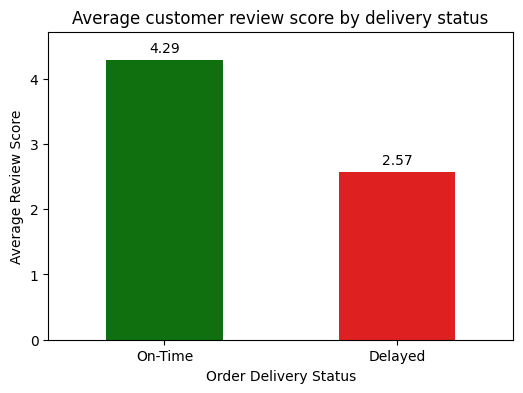

In [29]:
plt.figure(figsize=(6,4))
sns.barplot(data=delayed_means,x="is_delayed",y="review_score",hue="is_delayed",palette=(['green','red']),width=0.5)
plt.xlabel("Order Delivery Status")
plt.ylabel("Average Review Score")
plt.title("Average customer review score by delivery status")
plt.margins(y=0.1)
for container in plt.gca().containers:
    plt.gca().bar_label(container, padding=3)
plt.show()


**Insight: Delivery Performance and Customer Satisfaction**

The analysis shows a clear relationship between delivery performance and customer review scores.

Orders delivered on or before the estimated delivery date received an average review score of 4.29, while delayed orders received an average review score of 2.57.

This finding suggests that delivery performance is strongly associated with customer satisfaction. Lower review scores on delayed orders may negatively influence customer trust, repeat purchases, brand reputation, and long-term customer retention. Although this analysis does not establish causation, it highlights delivery delays as a key area requiring further investigation.


**The Next Question:** *Why are these delays happening?*

To provide actionable recommendations to the business, we need to locate the operational bottlenecks. We will conduct a **Root Cause Analysis (RCA)**.

Root Cause Analysis Objectives:

The next phase of the project investigates the following questions:

1. Which stage contributes more to delivery delays: seller processing time or carrier transit time?
2. How does delivery distance (inter-state vs. intra-state) affect carrier transit time and delivery delays?
3. Which product categories have the highest delayed delivery rate?
4. Which sellers consistently experience the highest delayed delivery rates?

By answering these questions, the project moves beyond measuring business impact and focuses on identifying actionable operational improvements that can reduce delivery delays and enhance the customer experience.

**Business question** : Which stage contributes more to delivery delays: seller processing time or carrier transit time?

The objective of this analysis is to compare seller processing time and carrier transit time to determine which operational stage contributes more to delivery delays. The findings will help the business identify where operational improvements should be prioritized.



In [30]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_delayed
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,On-Time
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,On-Time
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,On-Time
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,On-Time
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,On-Time


In [31]:
orders.isna().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
is_delayed                        0
dtype: int64

In [32]:
(orders["order_delivered_carrier_date"] - orders["order_approved_at"])/pd.Timedelta(days=1)

0        2.366493
1        0.462882
2        0.204595
3        3.745833
4        0.893113
           ...   
99436    1.058310
99437    1.425058
99438    1.241782
99439    3.749097
99440    0.452442
Length: 96476, dtype: float64

In [ ]:
# creating new features: "seller_processing_days" & "carrier_transit_days"

orders["seller_processing_days"]=(((orders["order_delivered_carrier_date"]-orders["order_approved_at"])).dt.total_seconds())/(24*3600)

orders['carrier_transit_days']=((orders["order_delivered_customer_date"]-orders["order_delivered_carrier_date"]).dt.total_seconds())/(24*3600)

#### Work in progress : Validating the seller processing days and carrier transit days features before metric calculation

In [34]:
orders[
    [
        "seller_processing_days",
        "carrier_transit_days"
    ]
].describe()

,seller_processing_days,carrier_transit_days
count,96461.000000,96475.000000
mean,2.799283,9.330547
std,3.537573,8.760122
min,-171.219005,-16.096169
25%,0.874363,4.099948
50%,1.815856,7.099769
75%,3.575208,12.029115
max,125.762569,205.190972


In [35]:

# Count of negative values in seller_processing_days column
orders["seller_processing_days"].lt(0).sum()



np.int64(1350)

In [36]:
# Statistical information about negative values only of seller_processing_days
orders.loc[
    orders["seller_processing_days"] < 0,
    "seller_processing_days"
].describe()

count    1350.000000
mean       -1.029290
std         4.818968
min      -171.219005
25%        -1.081389
50%        -0.714988
75%        -0.058869
max        -0.000243
Name: seller_processing_days, dtype: float64

In [117]:
# Look at first few negative values
orders.loc[
    orders["seller_processing_days"] < 0,
    "seller_processing_days"
].sort_values().head()

25883   -171.219005
14562     -9.372083
46163     -9.341262
98710     -9.163843
41592     -9.115104
Name: seller_processing_days, dtype: float64

In [38]:
# Negative values/days between -1 day and 0 days
orders[
    (orders["seller_processing_days"] < 0) &
    (orders["seller_processing_days"] >= -1)
].shape[0]

897

In [114]:
# Negative values/days less than -1 day
orders[
    orders["seller_processing_days"] < -1
].sort_values(by="seller_processing_days").head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_delayed,seller_processing_days,carrier_transit_days
25883,7c48bb55e8e4f7e56d412e9653db37bc,34ef6181341eb36c47fd601c46878f00,delivered,2018-07-16 18:40:53,2018-07-16 18:50:22,2018-01-26 13:35:00,2018-07-23 20:04:45,2018-08-07,On-Time,-171.219005,178.270660
14562,1fab4ac9d85079b3da72a11475ae1685,f831c1fa80308975ec2b58e4877328e0,delivered,2017-09-01 19:04:22,2017-09-13 22:06:11,2017-09-04 13:10:23,2017-09-08 20:13:03,2017-09-20,On-Time,-9.372083,4.293519
46163,0184d4ddb259e1a4cfc2871888cf97b8,09425ea1839abf2f0d289a0ff453fa21,delivered,2017-09-01 20:04:28,2017-09-13 22:17:15,2017-09-04 14:05:50,2017-09-09 15:12:44,2017-09-20,On-Time,-9.341262,5.046458
98710,1378f9601350615613cc8832d6789c5d,988126b4ddf725d9724e4318872ea2ae,delivered,2017-09-01 20:28:02,2017-09-13 22:03:51,2017-09-04 18:07:55,2017-09-13 22:24:46,2017-09-29,On-Time,-9.163843,9.178368
41592,8554cb37f7158cb0b082a841d24a4589,788e845925ff64c9df5d8ba40e28cf50,delivered,2017-09-01 18:40:44,2017-09-13 21:58:04,2017-09-04 19:12:19,2017-09-08 20:07:45,2017-10-02,On-Time,-9.115104,4.038495


In [ ]:
# Number of negative values/days in carrier delivery time
orders['carrier_transit_days'].lt(0).sum()

np.int64(23)

In [133]:
# Statistical information of negative values of carrier_delivery time
orders.loc[
    orders["carrier_transit_days"] < 0,
    "carrier_transit_days"
].describe()

count    23.000000
mean     -3.268964
std       3.721170
min     -16.096169
25%      -5.364959
50%      -1.661019
75%      -0.972431
max      -0.016181
Name: carrier_transit_days, dtype: float64

In [ ]:

orders.loc[
    (orders["carrier_transit_days"] < 0)&(orders['carrier_transit_days']>-1),
    [
        "order_id",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "carrier_transit_days"
    ]
].sort_values("carrier_transit_days").head()

,order_id,order_delivered_carrier_date,order_delivered_customer_date,carrier_transit_days
58428,fbffbaaa30f4077e87ec6acdb835b278,2017-08-04 20:04:17,2017-08-03 20:30:00,-0.982141
22520,b27af682321527a6349f1761eb3f360c,2017-06-27 14:51:54,2017-06-26 15:45:35,-0.962720
95634,f688669f48063536e082bb32d634cd46,2016-10-21 18:02:40,2016-10-20 20:33:27,-0.895289
21338,8c78d01de3a9009e23d6877a7cc9be20,2016-10-26 11:41:53,2016-10-25 17:51:46,-0.743137
19268,5f9d46795c3126674e52becb3a1a517f,2017-07-20 23:03:42,2017-07-20 18:52:41,-0.174317


In [ ]:
# Filtering out rows with negative values in seller and carrier delivery days column
invalid_rows = (orders['seller_processing_days'] < 0) | (orders['carrier_transit_days'] < 0)

# No. of negative value in the data
print(f"Total anomalous rows identified and dropped: {invalid_rows.sum()} ({invalid_rows.sum()/len(orders)*100:.2f}%)")

Total anomalous rows identified and dropped: 1373 (1.42%)


In [136]:
# Filtering out valid data
cleaned_df=orders[~invalid_rows].copy()

# Calculating metric for sellers delivery time and carriers delivery time
analysis_q1=cleaned_df.groupby("is_delayed")[["seller_processing_days","carrier_transit_days"]].mean().reset_index()
analysis_q1

,is_delayed,seller_processing_days,carrier_transit_days
0,Delayed,5.348614,25.681168
1,On-Time,2.629103,7.907836


In [137]:
# Reshaping data from wide to long format for better visualization
melted_df = pd.melt(analysis_q1, id_vars=['is_delayed'], 
                    value_vars=['seller_processing_days', 'carrier_transit_days'],
                    var_name='Fulfillment_Stage', value_name='Average_Days')
melted_df

,is_delayed,Fulfillment_Stage,Average_Days
0,Delayed,seller_processing_days,5.348614
1,On-Time,seller_processing_days,2.629103
2,Delayed,carrier_transit_days,25.681168
3,On-Time,carrier_transit_days,7.907836


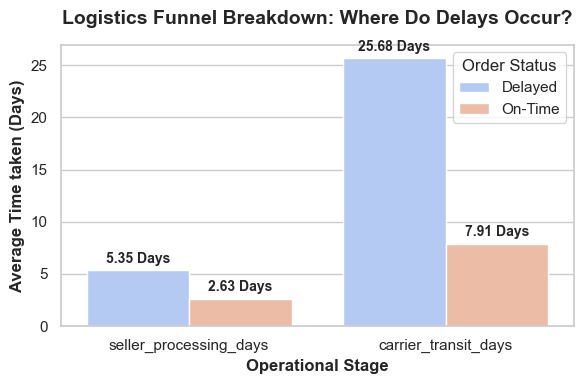

In [138]:
# Plotting
plt.figure(figsize=(6,4))
sns.set_theme(style="whitegrid")
ax = sns.barplot(data=melted_df, x='Fulfillment_Stage', y='Average_Days', hue='is_delayed', palette='coolwarm')

# Visual styling
plt.title('Logistics Funnel Breakdown: Where Do Delays Occur?', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Operational Stage', fontsize=12, fontweight='bold')
plt.ylabel('Average Time taken (Days)', fontsize=12, fontweight='bold')
plt.legend(title='Order Status')

# Annotate values on top of bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.2f} Days', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()